In [47]:
import numpy as np
import xarray as xr
import os
from matplotlib import pyplot as plt
from tqdm import tqdm
from wavediffusion.waveana import assemble 
%load_ext autoreload
%autoreload 2

# Open a random raw file to get lat and lon
ds = xr.open_dataset('/global/homes/j/jiarongw/scratch_folder/wave_data/raw/LOPS_WW3-GLOB-30M_202109.nc')
lat_deg = ds.latitude[1:-2].values
lon_deg = ds.longitude.values

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [48]:
ds

<xarray.Dataset> Size: 19GB
Dimensions:    (latitude: 323, longitude: 720, time: 240)
Coordinates:
  * latitude   (latitude) float32 1kB -78.0 -77.5 -77.0 -76.5 ... 82.0 82.5 83.0
  * longitude  (longitude) float32 3kB -180.0 -179.5 -179.0 ... 179.0 179.5
  * time       (time) datetime64[ns] 2kB 2021-09-01 ... 2021-09-30T21:00:00
Data variables: (12/86)
    MAPSTA     (latitude, longitude) int16 465kB ...
    dpt        (time, latitude, longitude) float32 223MB ...
    ucur       (time, latitude, longitude) float32 223MB ...
    vcur       (time, latitude, longitude) float32 223MB ...
    uwnd       (time, latitude, longitude) float32 223MB ...
    vwnd       (time, latitude, longitude) float32 223MB ...
    ...         ...
    vabr       (time, latitude, longitude) float32 223MB ...
    uubr       (time, latitude, longitude) float32 223MB ...
    vubr       (time, latitude, longitude) float32 223MB ...
    mssu       (time, latitude, longitude) float32 223MB ...
    mssc       (time, latitude, longitude) float32 223MB ...
    mssd       (time, latitude, longitude) float32 223MB ...
Attributes: (12/102)
    WAVEWATCH_III_version_number:     7.00
    WAVEWATCH_III_switches:           F90 NOGRB NC4 SCRIP SCRIPNC SHRD PR3 UQ...
    SIN4 namelist parameter BETAMAX:  1.75
    title:                            WAVEWATCH-III HINDCAST
    netcdf_version:                   4.5.2
    product_name:                     LOPS_WW3-GLOB-30M_202109.nc
    ...                               ...
    P2SF:                             1
    E3D:                              1
    I1P2SF:                           3
    I2P2SF:                           24
    start_date:                       2021-09-01 00:00:00
    stop_date:                        2021-09-30 21:00:00

In [9]:
# Sample scenario to analyze 2004_DDPM_40steps_100_20ensem_extra
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/2004_DDPM_40steps_100_20ensem_extra/'

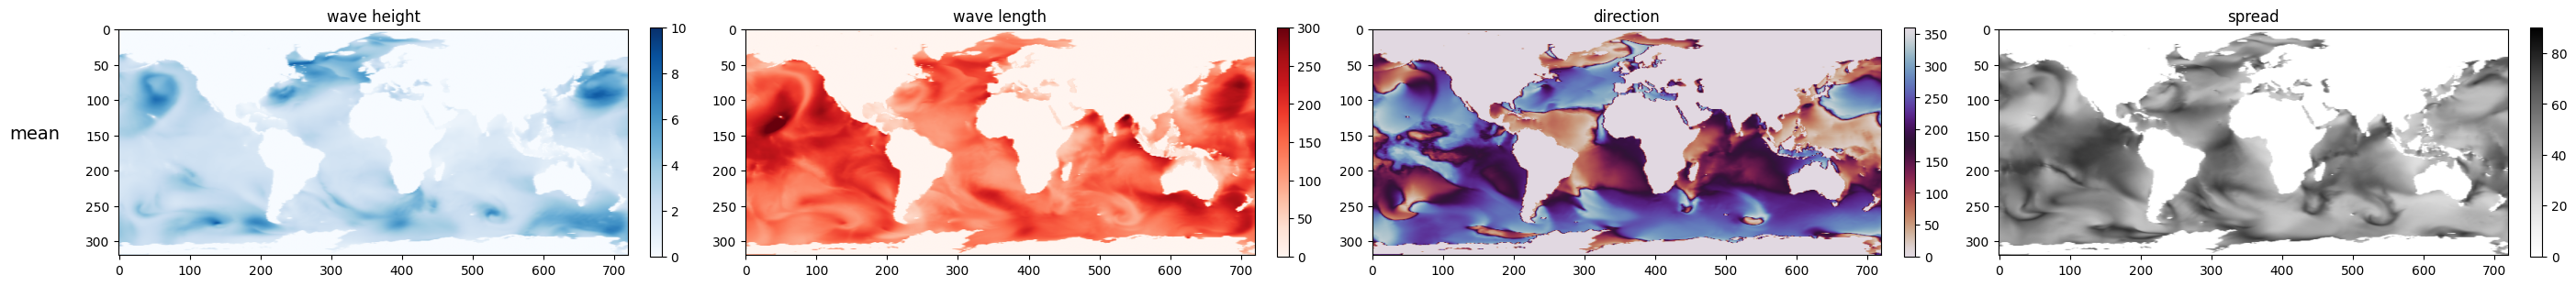

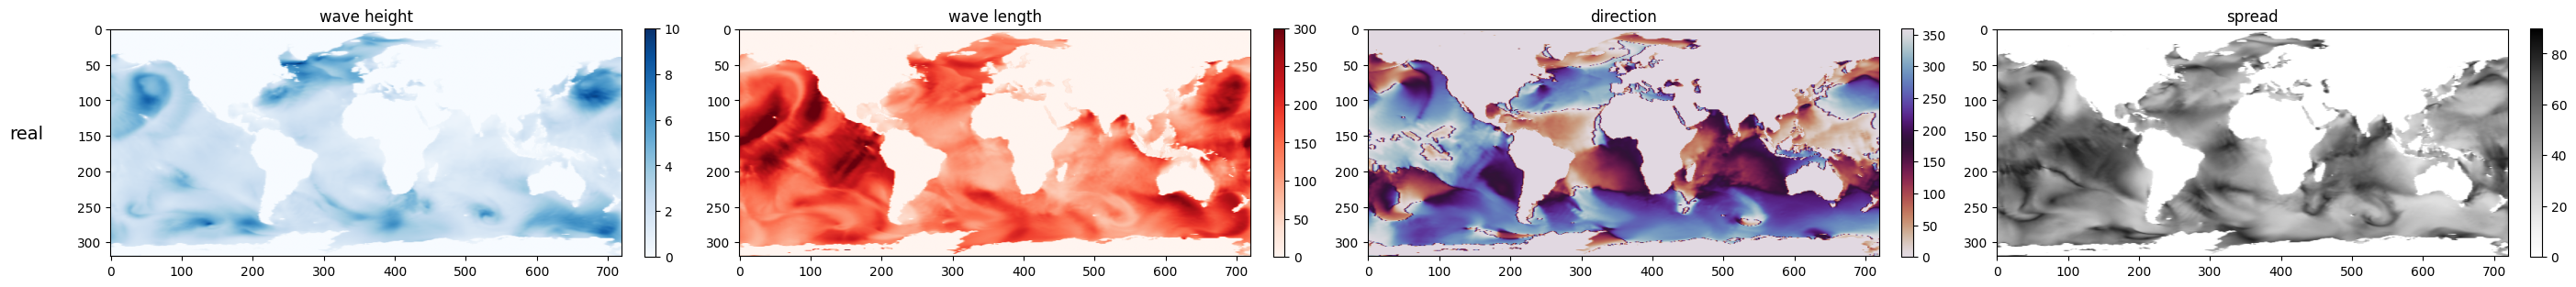

In [10]:
from wavediffusion.waveutils import plot_wave
index = 80
x_truth = np.load(f'{path}truth_{index}.npy')
mean = np.load(f'{path}mean_{index}.npy')
fig = plot_wave(mean[:,::-1], label='mean')
fig = plot_wave(x_truth[:,::-1], label='real')

In [12]:
# Sample scenario to analyze
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/plain_2004/'

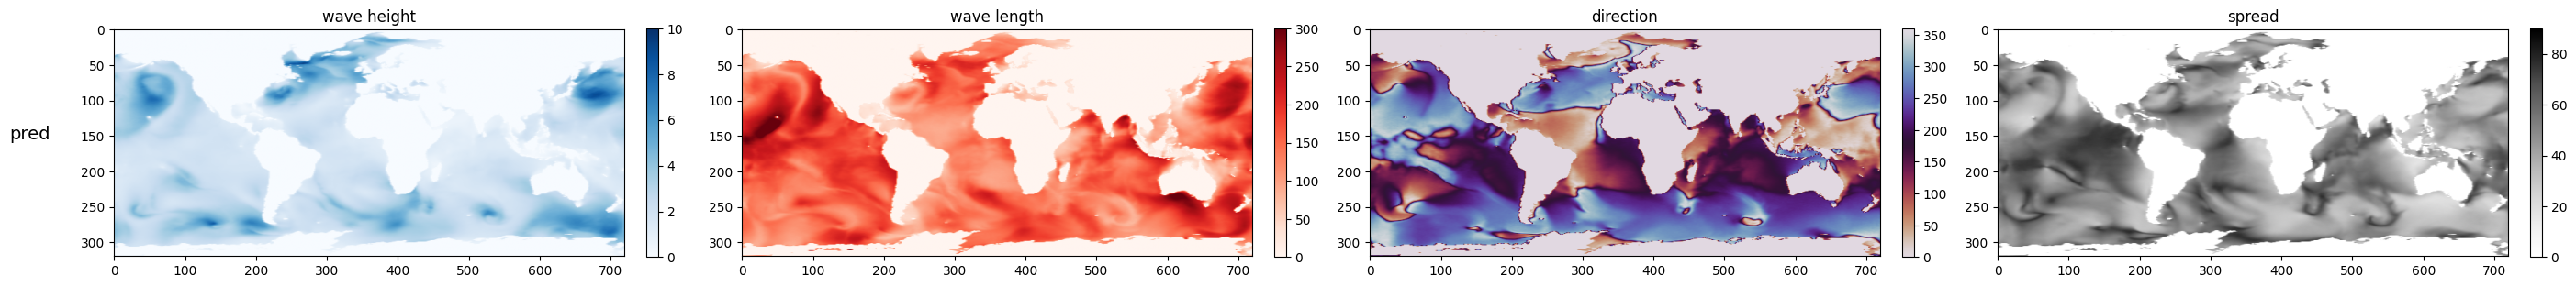

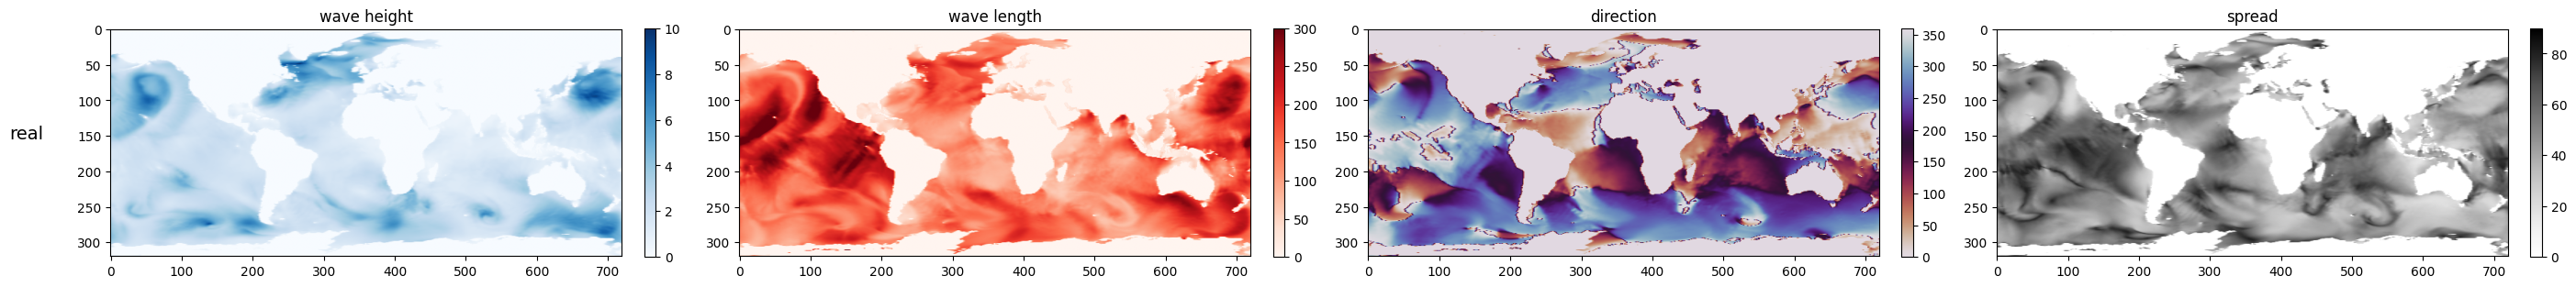

In [13]:
from wavediffusion.waveutils import plot_wave
index = 80
x_truth = np.load(f'{path}truth_{index}.npy')
mean = np.load(f'{path}pred_{index}.npy')
fig = plot_wave(mean[:,::-1], label='pred')
fig = plot_wave(x_truth[:,::-1], label='real')

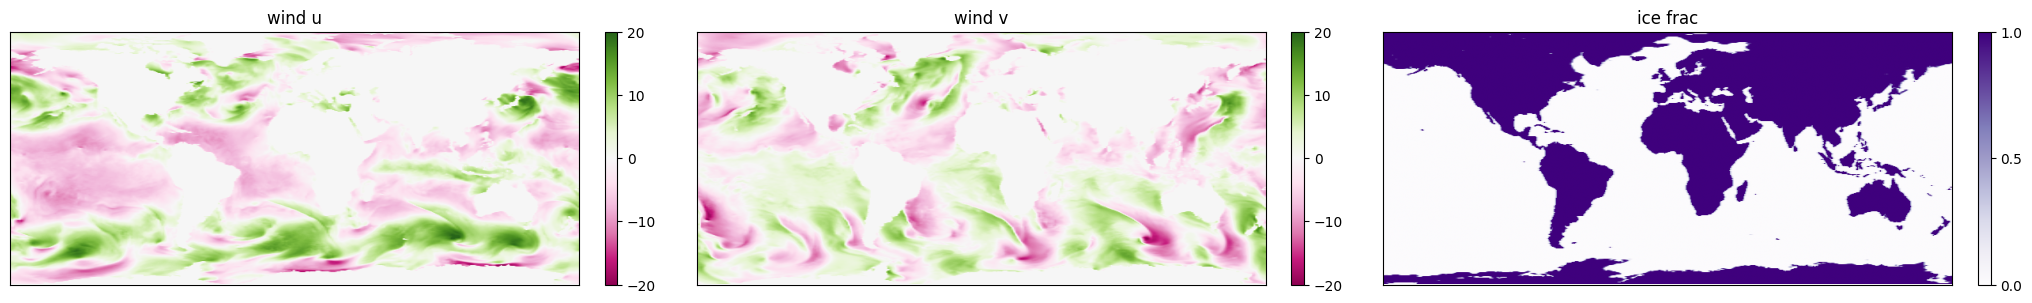

In [8]:
from wavediffusion.waveutils import plot_forcing
index = 320
f = np.load(f'{path}forcing_{index}.npy')
fig = plot_forcing(f[:,::-1])

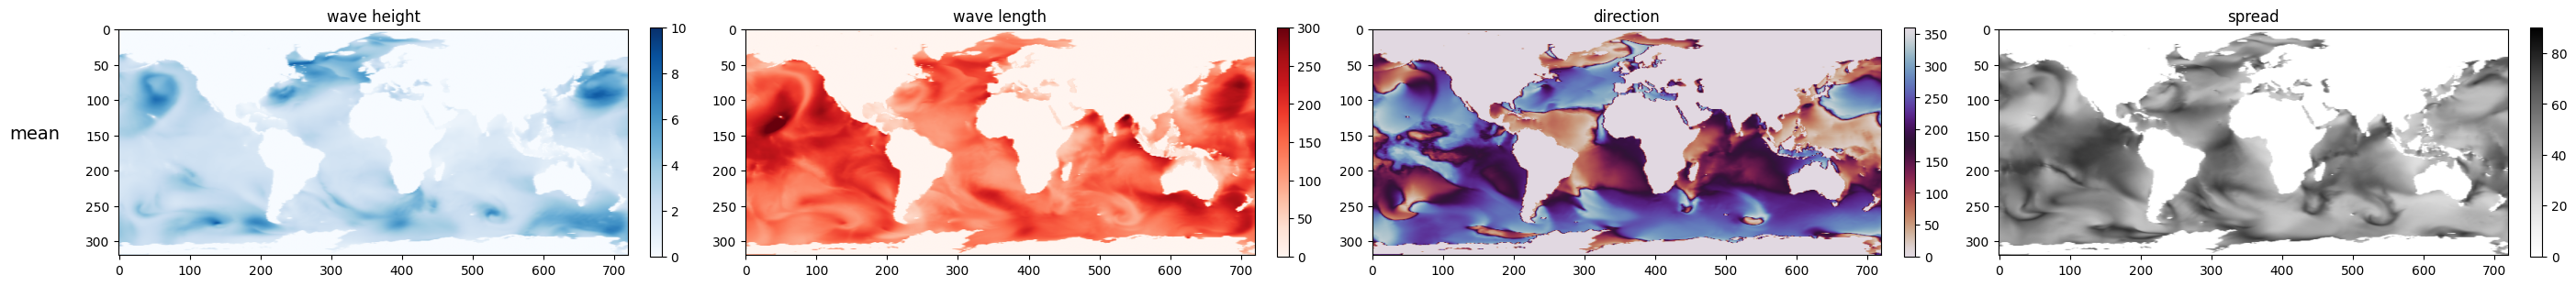

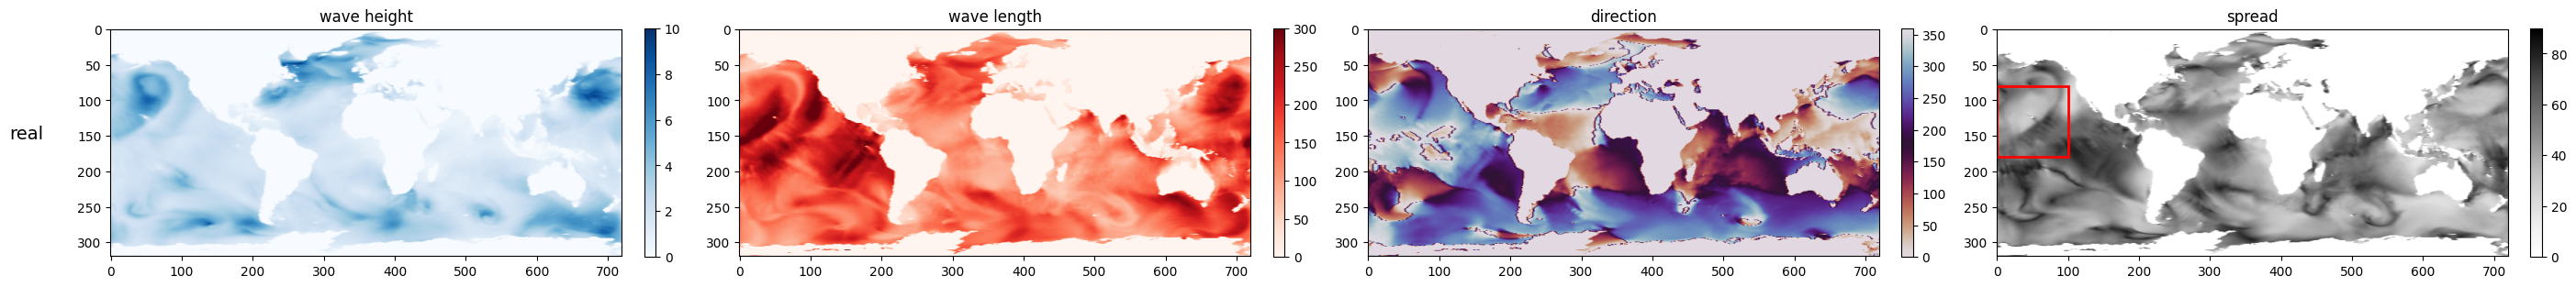

In [13]:
fig = plot_wave(mean[:,::-1], label='mean')
fig = plot_wave(x_truth[:,::-1], label='real')

ax = plt.gca()
import matplotlib.patches as patches

# Create a rectangle: (x, y), width, height
rect = patches.Rectangle((0, 80), 100, 100,
                         linewidth=2,
                         edgecolor='red',
                         facecolor='none')
ax.add_patch(rect)

In [16]:
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/200409_DDPM_40steps_100_20ensem_0.5d/'

index = 28
x_truth = np.load(f'{path}truth_{index}.npy')
x_mean = np.load(f'{path}mean_{index}.npy')
f = np.load(f'{path}forcing_{index}.npy')
truth = assemble(x_truth[0], x_truth[1], x_truth[2], (f[0]**2+f[1]**2)**0.5, f[2])
mean = assemble(x_mean[0], x_mean[1], x_mean[2], (f[0]**2+f[1]**2)**0.5, f[2])

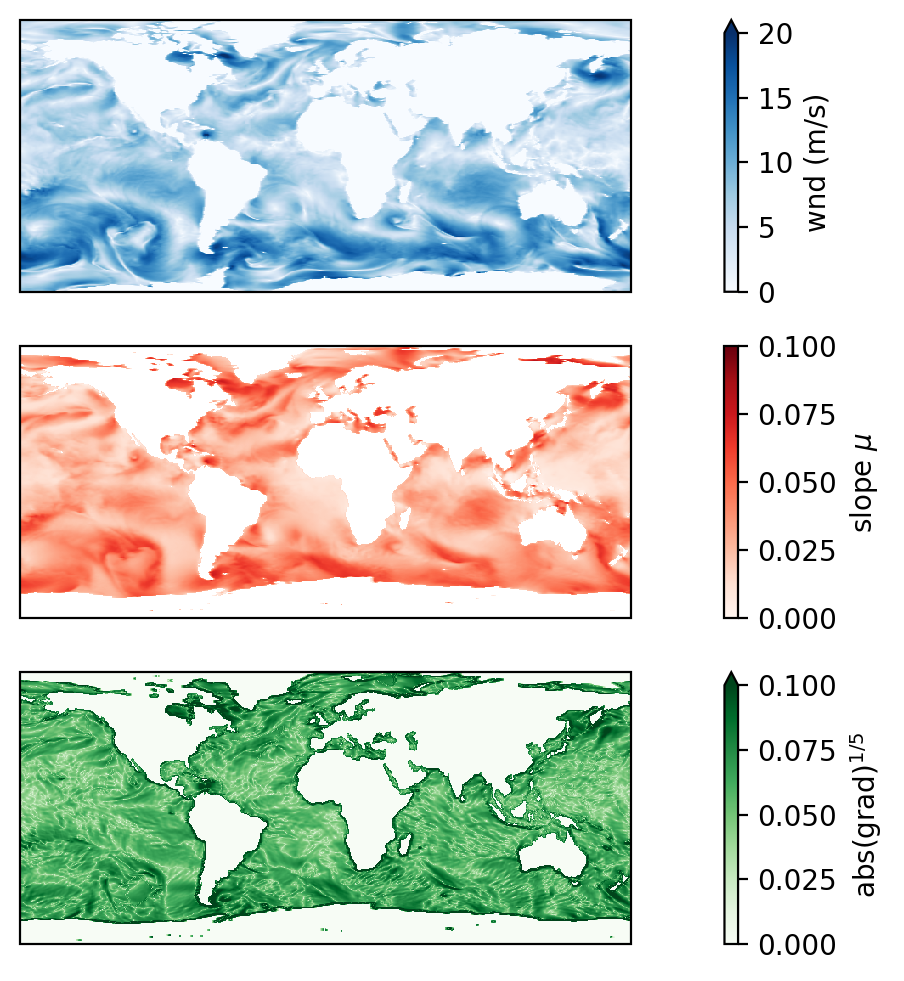

In [32]:
import cartopy.crs as ccrs
fig, axes = plt.subplots(3, 1, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[12,6], dpi=200)
truth.slope.plot(ax=axes[1], vmin=0, vmax=0.1, cmap='Reds', transform=ccrs.PlateCarree(), cbar_kwargs={'label': r'slope $\mu$'})
truth.wnd.plot(ax=axes[0],  vmin=0, vmax=20, cmap='Blues', transform=ccrs.PlateCarree(), cbar_kwargs={'label': 'wnd (m/s)'})
field = abs(truth.grad) ** 0.2
field.plot(ax=axes[2], vmax=0.1, vmin=0, cmap='Greens', transform=ccrs.PlateCarree(), cbar_kwargs={'label': 'abs(grad)$^{1/5}$'})

### Non-dimensional wave period and wave height

In [6]:
# Sample scenario to analyze
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/2004_DDPM_40steps_100_20ensem_extra/'

for i, index in enumerate(range(0, 320, 80)):
    x_truth = np.load(f'{path}truth_{index}.npy')
    x_mean = np.load(f'{path}mean_{index}.npy')
    # sample = np.load(f'{path}sample_{index}.npy')
    f = np.load(f'{path}forcing_{index}.npy') 
    if i == 0:
        truth = assemble(x_truth[0], x_truth[1], x_truth[2], (f[0]**2+f[1]**2)**0.5, f[2])
        mean = assemble(x_mean[0], x_mean[1], x_mean[2], (f[0]**2+f[1]**2)**0.5, f[2])
        # sampled = assemble(sample[0], sample[1], sample[2], (f[0]**2+f[1]**2)**0.5, f[2])
    else:
        t = assemble(x_truth[0], x_truth[1], x_truth[2], (f[0]**2+f[1]**2)**0.5, f[2])
        m = assemble(x_mean[0], x_mean[1], x_mean[2], (f[0]**2+f[1]**2)**0.5, f[2])
        # s = assemble(sample[0], sample[1], sample[2], (f[0]**2+f[1]**2)**0.5, f[2])
        truth = xr.concat([truth, t], dim="time")
        mean = xr.concat([mean, m], dim="time")
        # sampled = xr.concat([sampled, s], dim="time")

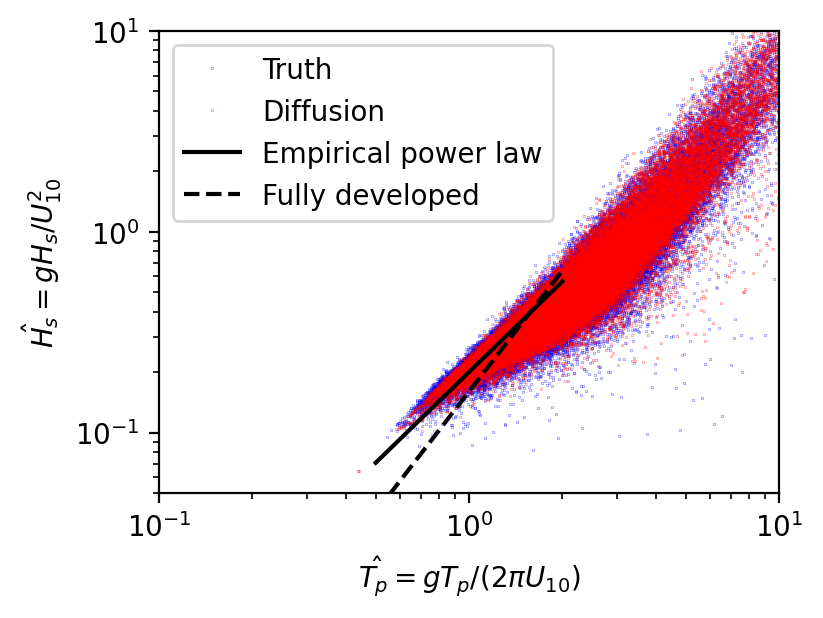

In [12]:
plt.figure(figsize=[4,3], dpi=200)

tp_hat = truth.tp_hat.where(truth.ice==1, drop=True).values.flatten()
hs_hat = truth.hs_hat.where(truth.ice==1, drop=True).values.flatten()
plt.plot(tp_hat, hs_hat, 'o', markersize=0.1, c='blue', label='Truth')
tp_hat = mean.tp_hat.where(truth.ice==1, drop=True).values.flatten()
hs_hat = mean.hs_hat.where(truth.ice==1, drop=True).values.flatten()
plt.plot(tp_hat, hs_hat, 'o', markersize=0.1, c='red', label='Diffusion')
plt.xlim([0.1, 10]); plt.ylim([0.05, 10]); plt.yscale('log'); plt.xscale('log')

# Plot some empirical relations
x = np.linspace(0.5, 2)
plt.plot(x, 0.2*x**1.5, c='k', label='Empirical power law')
plt.plot(x, 0.04*4*x**2, c='k', ls='--', label='Fully developed')

plt.xlabel(r'$\hat{T_p} = gT_p/(2\pi U_{10})$')
plt.ylabel(r'$\hat{H_s} = gH_s/U_{10}^2$')
plt.legend()

In [13]:
from scipy.stats import gaussian_kde
from matplotlib.lines import Line2D
import matplotlib.colors as colors

# Grid (once)
xi_log, yi_log = np.mgrid[
    np.log10(0.5):np.log10(10):100j,
    np.log10(0.08):np.log10(10):100j
]
grid_points = np.vstack([xi_log.ravel(), yi_log.ravel()])

xi = 10**xi_log
yi = 10**yi_log

# --- Truth ---
log_right = np.log10(truth.tp_hat.where(truth.ice==1).values.flatten())
log_left = np.log10(truth.hs_hat.where(truth.ice==1).values.flatten())
mask = np.isfinite(log_left) & np.isfinite(log_right)
if mask.sum() > 0:
    print('There are NANs in truth.')
k1 = gaussian_kde([log_right[mask], log_left[mask]])
zi1 = k1(grid_points)

# --- Model ---
log_right = np.log10(mean.tp_hat.where(mean.ice==1).values.flatten())
log_left = np.log10(mean.hs_hat.where(mean.ice==1).values.flatten())
mask = np.isfinite(log_left) & np.isfinite(log_right)
if mask.sum() > 0:
    print('There are NANs in model.')
k2 = gaussian_kde([log_right[mask], log_left[mask]])
zi2 = k2(grid_points)

There are NANs in truth.
There are NANs in model.


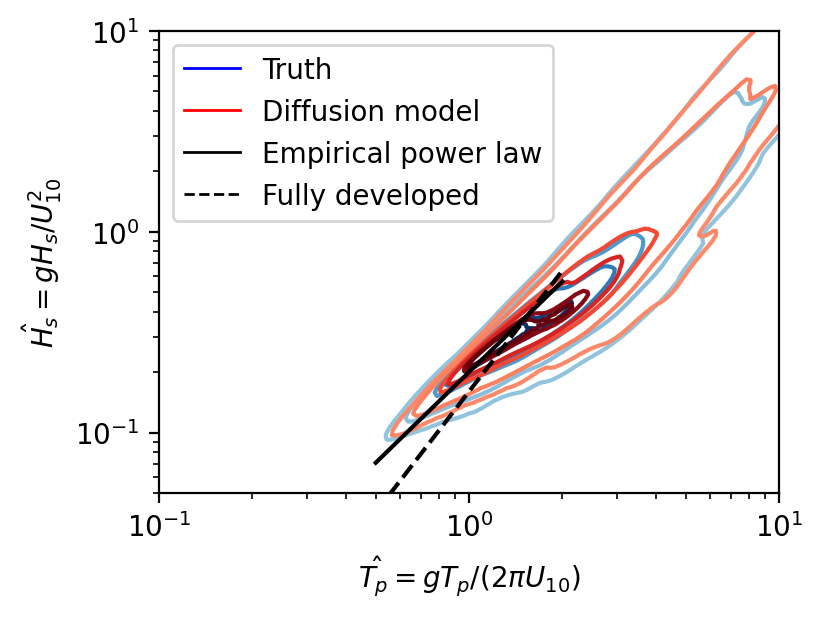

In [15]:
# Plot the contours
plt.figure(figsize=[4,3], dpi=200)

# Shared contour levels
# Need to find the colormap better
levels = np.percentile(np.hstack([zi1, zi2]), [75, 85, 95, 97, 99, 99.5])
norm = colors.Normalize(vmin=levels[0]-5, vmax=levels[-1])
# Plot
plt.contour(xi, yi, zi1.reshape(xi.shape), cmap='Blues', levels=levels, norm=norm)
plt.contour(xi, yi, zi2.reshape(xi.shape), cmap='Reds', levels=levels, norm=norm)

# Power law
x = np.linspace(0.5, 2)
plt.plot(x, 0.2*x**1.5, c='k')
plt.plot(x, 0.04*4*x**2, c='k', ls='--')

# Axes
plt.xlim([0.1, 10]); plt.ylim([0.05, 10]); plt.yscale('log'); plt.xscale('log')
plt.xlabel(r'$\hat{T_p} = gT_p/(2\pi U_{10})$')
plt.ylabel(r'$\hat{H_s} = gH_s/U_{10}^2$')

# Legend
legend_lines = [
    Line2D([0], [0], color='blue', lw=1),
    Line2D([0], [0], color='red', lw=1),
    Line2D([0], [0], color='black', lw=1),
    Line2D([0], [0], color='black', ls='--', lw=1)
]
plt.legend(legend_lines,
           ['Truth', 'Diffusion model', 'Empirical power law', 'Fully developed'], loc='upper left')

(0.0, 14.0)

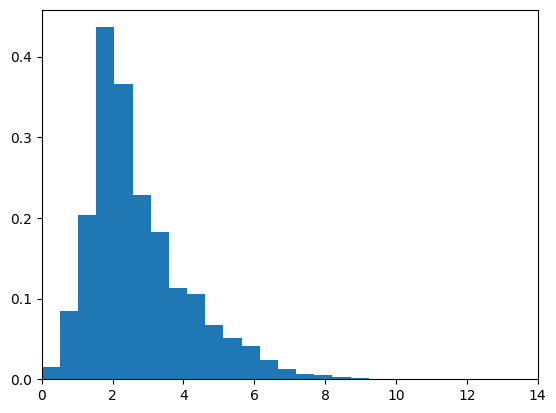

In [7]:
# Wave height distribution
plt.hist(x_truth[0][icymask], bins=np.linspace(0,20,40), density=True)
plt.xlim([0,14])

### Metrics binned with wave height

In [33]:
def binned_metrics(path, bins, PLAIN=False):
    snapshots = []
    for index in tqdm(range(0, 2880, 80)):
        x_truth  = np.load(f'{path}truth_{index}.npy')
        if PLAIN: # deterministic model
            x_pred = np.load(f'{path}pred_{index}.npy')
        else: # diffusion model
            x_pred = np.load(f'{path}mean_{index}.npy')
        forcing  = np.load(f'{path}forcing_{index}.npy')
    
        ds = xr.Dataset({
            'hs_truth': (('lat', 'lon'), x_truth[0]),
            'lp_truth': (('lat', 'lon'), x_truth[1]),
            'hs_pred':  (('lat', 'lon'), x_pred[0]),
            'lp_pred':  (('lat', 'lon'), x_pred[1]),
            'ice':      (('lat', 'lon'), forcing[2]),
        }, coords={'lat': lat_deg, 'lon': lon_deg})
        snapshots.append(ds)
    
    ds_all = xr.concat(snapshots, dim='snapshot')
    ds_ice = ds_all.where(ds_all.ice == 1, drop=True)
    ds_ice['hs_diff'] = (ds_ice.hs_truth - ds_ice.hs_pred) ** 2
    ds_ice['lp_diff'] = (ds_ice.lp_truth - ds_ice.lp_pred) ** 2
    
    bin_edges = list(bins) + [np.inf]
    grouped = ds_ice[['hs_diff', 'lp_diff']].groupby_bins(
        ds_ice.hs_truth, bins=bin_edges, right=False
    )
    n_count = grouped.count().hs_diff.values
    metric1 = grouped.mean().hs_diff.values
    metric2 = grouped.mean().lp_diff.values
    
    return n_count, metric1, metric2

In [34]:
path1 = '/global/homes/j/jiarongw/wavediffusion/example/temp/2004_DDPM_40steps_100_20ensem_extra/'
path2 = '/global/homes/j/jiarongw/wavediffusion/example/temp/plain_2004/'
bins = (0, 1, 2, 3, 4, 5, 6, 8)
n_count, hs_mse, lp_mse = binned_metrics(path1, bins)
n_count_plain, hs_mse_plain, lp_mse_plain = binned_metrics(path2, bins, PLAIN=True)

100%|██████████| 36/36 [00:02<00:00, 16.87it/s]


In [24]:
print(n_count, n_count_plain)

[ 26553 173651 177897  82294  42858  20535  12310   1743] [ 26553 173651 177897  82294  42858  20535  12310   1743]


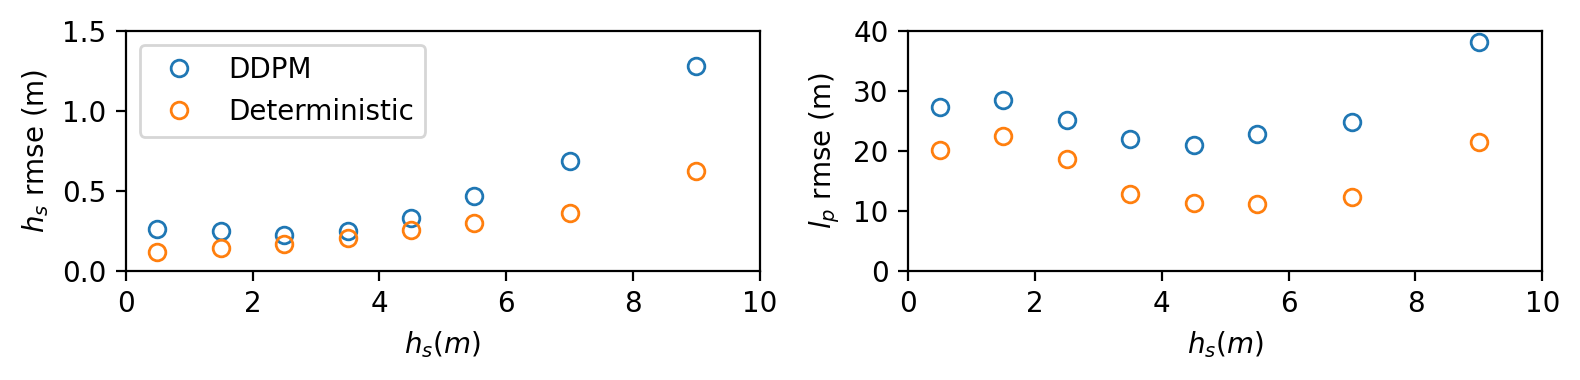

In [40]:
fig, axes = plt.subplots(1, 2, figsize=[8,2], dpi=200)
bin_centers = [(a + b) / 2 for a, b in zip(bins[:-1], bins[1:])]
bin_centers.append(bins[-1] + 1)
axes[0].plot(bin_centers, hs_mse**0.5, 'o', mfc='none', label='DDPM')
axes[0].plot(bin_centers, hs_mse_plain**0.5, 'o', mfc='none', label='Deterministic')
axes[1].plot(bin_centers, lp_mse**0.5, 'o', mfc='none', label='DDPM')
axes[1].plot(bin_centers, lp_mse_plain**0.5, 'o', mfc='none', label='Deterministic')
axes[0].set_ylim([0,1.5]); axes[0].set_xlim([0,10]); axes[0].set_xlabel(r'$h_s (m)$'); axes[0].set_ylabel(r'$h_s$ rmse (m)')
axes[1].set_ylim([0,40]); axes[1].set_xlim([0,10]); axes[1].set_xlabel(r'$h_s (m)$'); axes[1].set_ylabel(r'$l_p$ rmse (m)')
axes[0].legend()
plt.tight_layout()

In [42]:
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/2004_DDPM_40steps_100_20ensem_extra/'
bins = (0, 1, 2, 3, 4, 5, 6, 8)

snapshots = []
for index in tqdm(range(0, 6*80, 80)):
    x_truth = np.load(f'{path}truth_{index}.npy')
    x_mean = np.load(f'{path}mean_{index}.npy')
    x_std = np.load(f'{path}std_{index}.npy')
    forcing  = np.load(f'{path}forcing_{index}.npy')

    ds = xr.Dataset({
        'hs_truth': (('lat', 'lon'), x_truth[0]),
        'lp_truth': (('lat', 'lon'), x_truth[1]),        
        'hs_std': (('lat', 'lon'), x_std[0]),
        'lp_std': (('lat', 'lon'), x_std[1]),
        'hs_mean':  (('lat', 'lon'), x_mean[0]),
        'lp_mean':  (('lat', 'lon'), x_mean[1]),
        'ice':      (('lat', 'lon'), forcing[2]),
    }, coords={'lat': lat_deg, 'lon': lon_deg})
    snapshots.append(ds)

ds_all = xr.concat(snapshots, dim='snapshot')
ds_ice = ds_all.where(ds_all.ice > 0.99, drop=True)

100%|██████████| 6/6 [00:00<00:00, 21.68it/s]


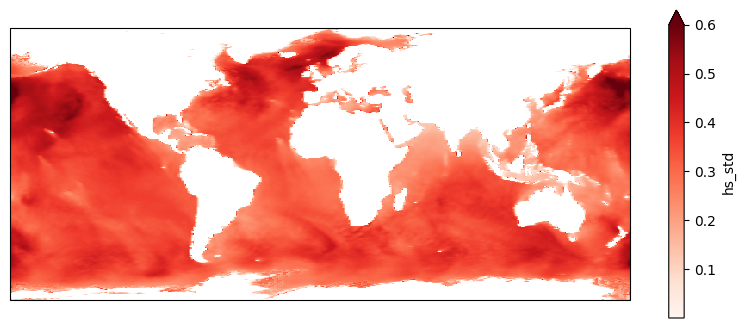

In [71]:
import cartopy.crs as ccrs
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
std = ds_ice.hs_std.mean(dim='snapshot')
std.plot(ax=ax, vmax=0.6, cmap='Reds', transform=ccrs.PlateCarree())

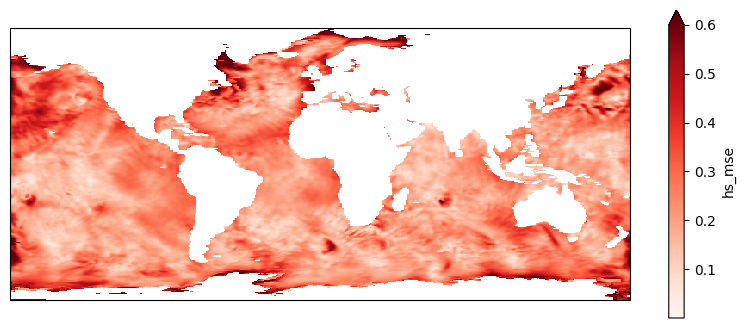

In [43]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ds_ice['hs_mse'] = (ds_ice['hs_truth'] - ds_ice['hs_mean']) ** 2
rmse = ds_ice.hs_mse.mean(dim='snapshot') ** 0.5
rmse.plot(ax=ax, vmax=0.6, cmap='Reds', transform=ccrs.PlateCarree())

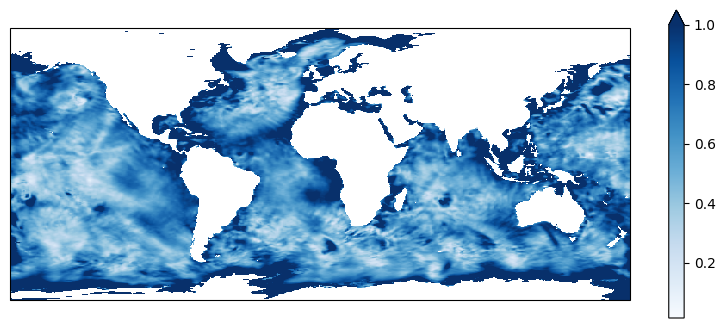

In [74]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ratio = rmse / std
ratio.plot(ax=ax, vmax=1, cmap='Blues', transform=ccrs.PlateCarree())

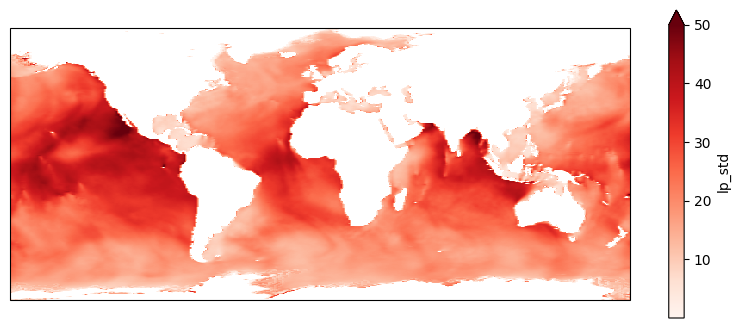

In [75]:
import cartopy.crs as ccrs
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
std = ds_ice.lp_std.mean(dim='snapshot')
std.plot(ax=ax, vmax=50, cmap='Reds', transform=ccrs.PlateCarree())

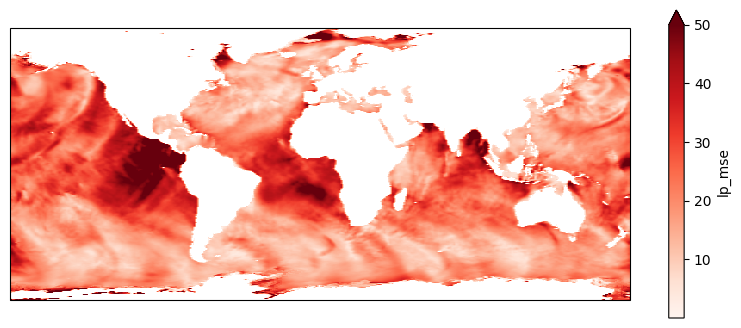

In [76]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ds_ice['lp_mse'] = (ds_ice['lp_truth'] - ds_ice['lp_mean']) ** 2
rmse = ds_ice.lp_mse.mean(dim='snapshot') ** 0.5
rmse.plot(ax=ax, vmax=50, cmap='Reds', transform=ccrs.PlateCarree())

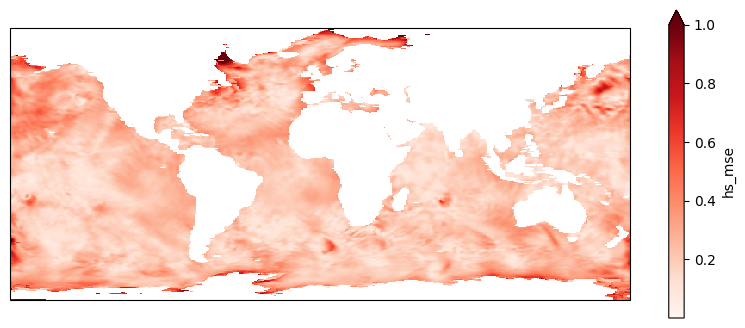

In [46]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ds_ice['hs_mse'] = (ds_ice['hs_truth'] - ds_ice['hs_mean']) ** 2
rmse = ds_ice.hs_mse.mean(dim='snapshot') ** 0.5
rmse.plot(ax=ax, vmax=1, cmap='Reds', transform=ccrs.PlateCarree())

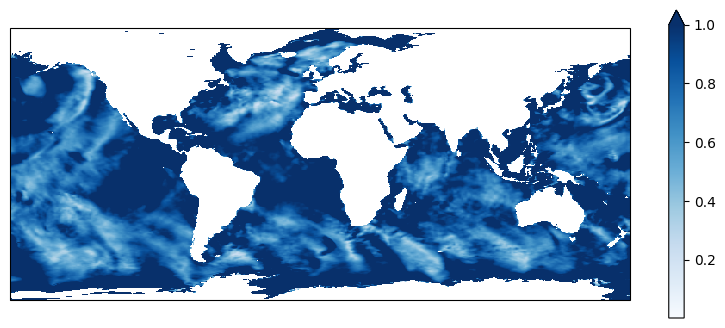

In [77]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ratio = rmse / std
ratio.plot(ax=ax, vmax=1, cmap='Blues', transform=ccrs.PlateCarree())

In [90]:
path = '/global/homes/j/jiarongw/wavediffusion/example/temp/plain_200403/'

snapshots = []
for index in tqdm(range(0, 180, 4)):
    x_truth = np.load(f'{path}truth_{index}.npy')
    x_mean = np.load(f'{path}pred_{index}.npy')
    forcing  = np.load(f'{path}forcing_{index}.npy')

    ds = xr.Dataset({
        'hs_truth': (('lat', 'lon'), x_truth[0]),
        'lp_truth': (('lat', 'lon'), x_truth[1]),        
        'hs_mean':  (('lat', 'lon'), x_mean[0]),
        'lp_mean':  (('lat', 'lon'), x_mean[1]),
        'ice':      (('lat', 'lon'), forcing[2]),
    }, coords={'lat': lat_deg, 'lon': lon_deg})
    snapshots.append(ds)

ds_all = xr.concat(snapshots, dim='snapshot')
ds_ice = ds_all.where(ds_all.ice > 0, drop=True)

100%|██████████| 45/45 [00:04<00:00, 11.24it/s]


In [ ]:
fig, axes = plt.subplots(1, 2, subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ds_ice = ds_all.where(ds_all.ice > 0, drop=True)
ds_ice['hs_mse'] = (ds_ice['hs_truth'] - ds_ice['hs_mean']) ** 2
hs_rmse = ds_ice.hs_mse.mean(dim='snapshot') ** 0.5
ds_ice['lp_mse'] = (ds_ice['lp_truth'] - ds_ice['lp_mean']) ** 2
lp_rmse = ds_ice.lp_mse.mean(dim='snapshot') ** 0.5
hs_rmse.plot(ax=axes[0], vmax=0.6, cmap='Reds', transform=ccrs.PlateCarree(), )
lp_rmse.plot(ax=axes[1], vmax=50, cmap='Reds', transform=ccrs.PlateCarree(), )
plt.tight_layout()

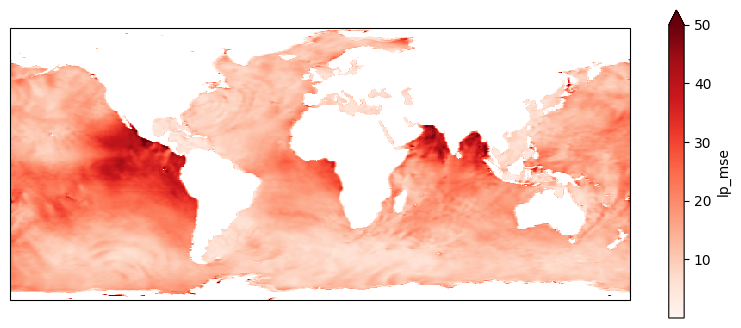

In [92]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.PlateCarree()}, figsize=[10,4])
ds_ice = ds_all.where(ds_all.ice > 0, drop=True)
ds_ice['lp_mse'] = (ds_ice['lp_truth'] - ds_ice['lp_mean']) ** 2
rmse = ds_ice.lp_mse.mean(dim='snapshot') ** 0.5
rmse.plot(ax=ax, vmax=50, cmap='Reds', transform=ccrs.PlateCarree())